<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: Iris Xia
<br>
Github Username: xd11997
<br>
USC ID: 1152659547

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.stats.anova import anova_lm

Get the Cycle Power Plant Data Set

In [60]:
df = pd.read_excel("./CCPP/Folds5x2_pp.xlsx")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [61]:
df.shape

(9568, 5)

- There are 9568 rows and 5 columns in this dataset.
- Each row represents one hourly observation of the power plant under full load. 
- The columns represent four environmental features—ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH),plus the target variable, net hourly electrical energy output (PE).

#### ii. pairwise scatterplots of all the varianbles

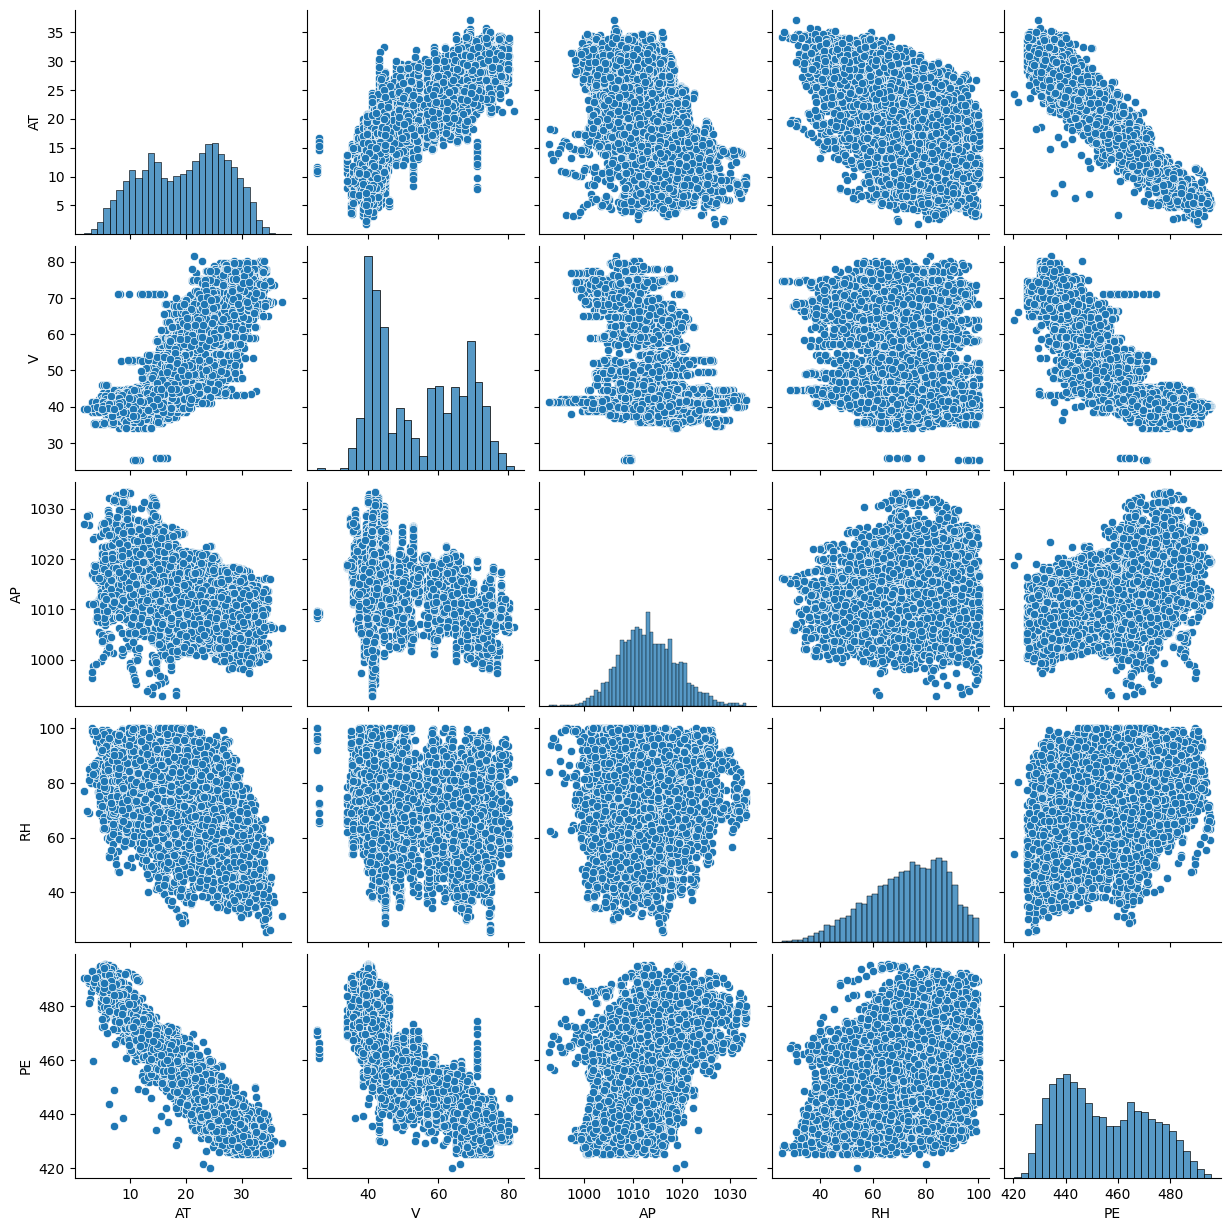

In [62]:
sns.pairplot(df)
plt.show()

- PE has strong negative linear relationship with AT and a noticeable negative linear relationship with V.
- AP has a weaker positive association with PE, while the relationship between RH and PE is weaker and less clearly linear.
- Among the predictors, AT and V exhibit a noticeable positive association, while the relationships among the other predictors are relatively less obvious.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [63]:
summary = df.describe()

summary.loc['range'] = summary.loc['max'] - summary.loc['min']
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']

summary = summary.loc[['mean', '50%', 'range', '25%', '75%', 'IQR']].round(2)
summary = summary.rename(index={'50%': 'median'})
summary

,AT,V,AP,RH,PE
mean,19.65,54.31,1013.26,73.31,454.37
median,20.34,52.08,1012.94,74.97,451.55
range,35.30,56.20,40.41,74.60,75.50
25%,13.51,41.74,1009.10,63.33,439.75
75%,25.72,66.54,1017.26,84.83,468.43
IQR,12.21,24.80,8.16,21.50,28.68


### (c) Simple Linear Regression

In [64]:
predictors = df.drop(columns=['PE'])

models = {}

for predictor in predictors.columns:
    X = sm.add_constant(df[predictor])
    y = df['PE']
    model = sm.OLS(y, X).fit()
    models[predictor] = model

    print(f"Model for {predictor}:")
    print(model.summary())

Model for AT:
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:03   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   317

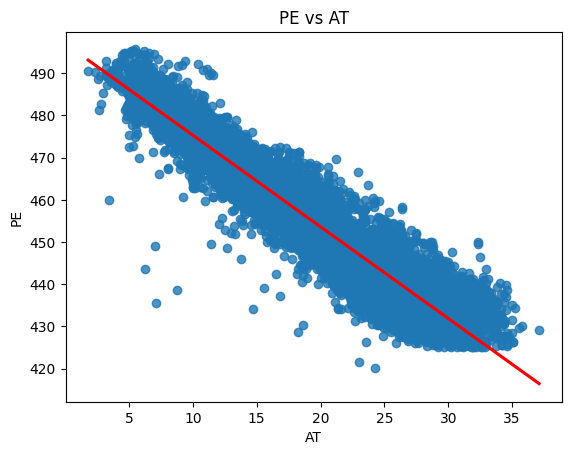

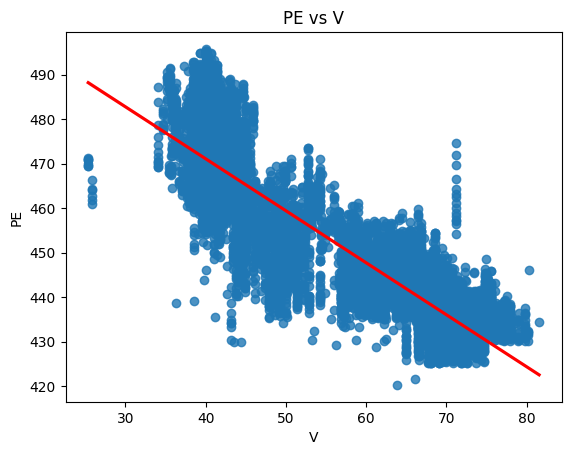

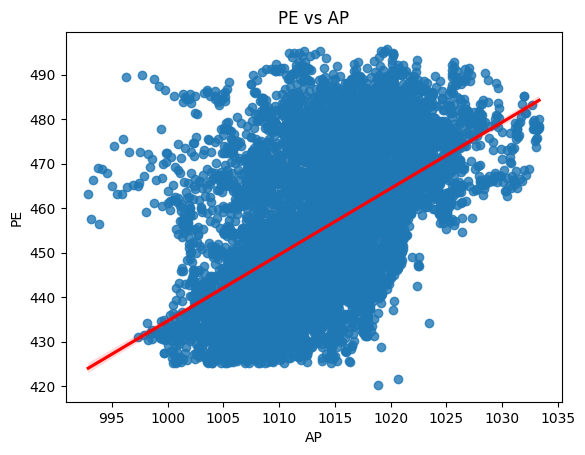

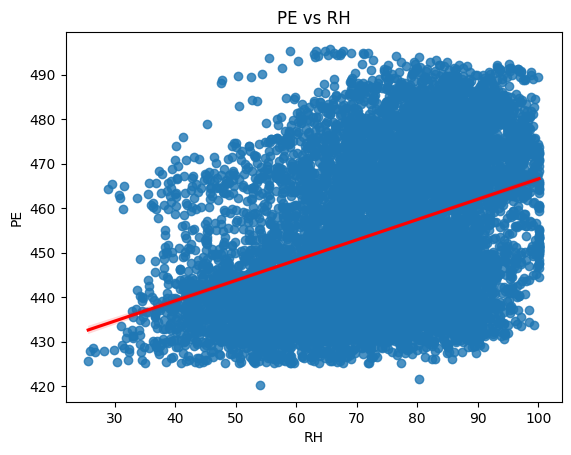

In [65]:
for predictor in predictors:
    sns.regplot(
        x=predictor,
        y='PE',
        data=df,
        line_kws={'color': 'red'}
    )
    plt.title(f'PE vs {predictor}')
    plt.show()

AT: 42 potential outliers
V: 33 potential outliers
AP: 30 potential outliers
RH: 2 potential outliers


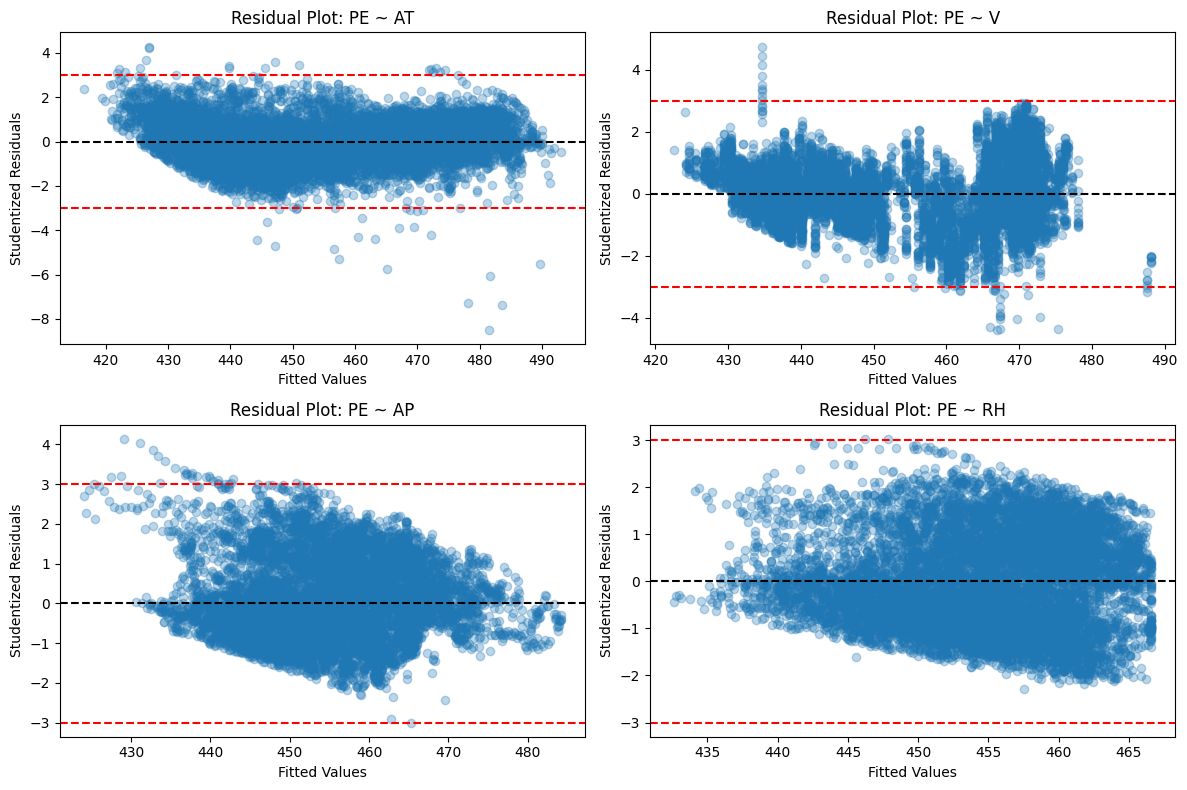

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    model = models[predictor]
    
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_external
    
    axes[i].scatter(
        model.fittedvalues,
        studentized_residuals,
        alpha=0.3
    )
    
    axes[i].axhline(0, color='black', linestyle='--')
    axes[i].axhline(3, color='red', linestyle='--')
    axes[i].axhline(-3, color='red', linestyle='--')
    
    axes[i].set_xlabel('Fitted Values')
    axes[i].set_ylabel('Studentized Residuals')
    axes[i].set_title(f'Residual Plot: PE ~ {predictor}')
    
    n_outliers = np.sum(np.abs(studentized_residuals) > 3)
    print(f'{predictor}: {n_outliers} potential outliers')

plt.tight_layout()
plt.show()

- All four predictors have statistically significant associations with PE (p < 0.001). AT and V have negative coefficients of −2.1713 and −1.1681, respectively, whereas AP and RH have positive coefficients of 1.4899 and 0.4557. 
- The strength of the relationships differs substantially. AT has the highest R-squared (0.899), followed by V (0.757), indicating strong negative relationships with PE. In contrast, AP (R² = 0.269) and RH (R² = 0.152) explain substantially less variation in PE despite their statistically significant coefficients. The scatterplots are consistent with these results, as observations are much more tightly concentrated around the fitted line for AT and V than for AP and RH. 
- Potential outliers were identified using externally studentized residuals, with observations having \(|r_i|>3\) flagged as potential outliers. Several such observations are present, particularly in some of the simple regression models. However, I would not remove them solely based on large residuals, since there is no evidence that these observations are erroneous.

### (d) Multiple Regression

In [66]:
import statsmodels.api as sm

X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

X = sm.add_constant(X)

model_multiple = sm.OLS(y, X).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:06   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

We can reject the null hypothesis \(H_0:\beta_j=0\) for all four predictors (AT, V, AP, and RH) at the 0.05 significance level.

### (e) 1c Compare to 1d

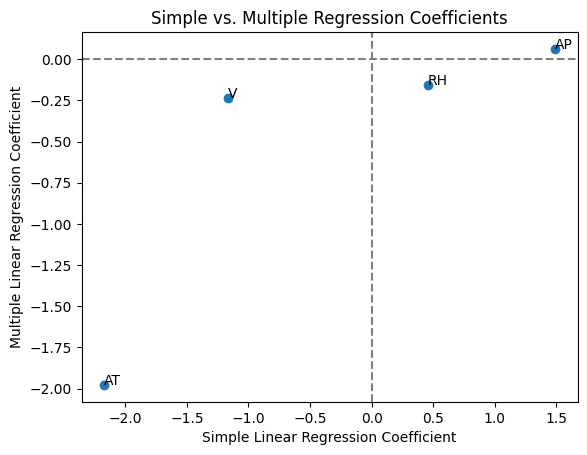

In [67]:
predictors = ['AT', 'V', 'AP', 'RH']

simple_coefs = [models[p].params[p] for p in predictors]
multiple_coefs = [model_multiple.params[p] for p in predictors]

plt.scatter(simple_coefs, multiple_coefs)

for i, predictor in enumerate(predictors):
    plt.annotate(
        predictor,
        (simple_coefs[i], multiple_coefs[i])
    )

plt.xlabel('Simple Linear Regression Coefficient')
plt.ylabel('Multiple Linear Regression Coefficient')
plt.title('Simple vs. Multiple Regression Coefficients')

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.show()

- The coefficient estimates differ substantially between the simple and multiple regression models. 
- The coefficient for AT remains negative and changes relatively little, from -2.1713 to -1.9775. 
- The coefficient for V remains negative but decreases considerably in magnitude, from -1.1681 to -0.2339, while the coefficient for AP decreases from 1.4899 to 0.0621. 
- Most notably, the coefficient for RH changes sign, from 0.4557 in the simple regression to -0.1581 in the multiple regression. These differences arise because the simple regressions examine each predictor separately, whereas the multiple regression estimates the association between each predictor and PE while holding the other predictors constant. Since some of the predictors are correlated with one another, their estimated coefficients can change substantially after controlling for the other variables.

### (f) Nonlinear Association

In [68]:
predictors = ['AT', 'V', 'AP', 'RH']

poly_models = {}

for predictor in predictors:
    X = pd.DataFrame({
        predictor: df[predictor],
        f'{predictor}^2': df[predictor] ** 2,
        f'{predictor}^3': df[predictor] ** 3
    })
    
    X = sm.add_constant(X)
    y = df['PE']
    
    model = sm.OLS(y, X).fit()
    poly_models[predictor] = model
    
    print(f'Polynomial Regression: {predictor} vs PE')
    print(model.summary())

Polynomial Regression: AT vs PE
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:06   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.728

In [69]:
results = []

for predictor in predictors:
    model = poly_models[predictor]
    
    results.append({
        'Predictor': predictor,
        'Linear p-value': model.pvalues[predictor],
        'Quadratic p-value': model.pvalues[f'{predictor}^2'],
        'Cubic p-value': model.pvalues[f'{predictor}^3'],
        'R-squared': model.rsquared
    })

poly_results = pd.DataFrame(results)
poly_results

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


In [97]:
comparison = []

for predictor in predictors:
    linear_model = models[predictor]
    cubic_model = poly_models[predictor]
    
    f_test = anova_lm(linear_model, cubic_model)
    joint_pvalue = f_test['Pr(>F)'].iloc[1]
    
    comparison.append({
        'Predictor': predictor,
        'Linear R-squared': linear_model.rsquared,
        'Cubic R-squared': cubic_model.rsquared,
        'R-squared Improvement': (
            cubic_model.rsquared - linear_model.rsquared
        ),
        'Joint F-test P-value': joint_pvalue
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Predictor,Linear R-squared,Cubic R-squared,R-squared Improvement,Joint F-test P-value
0,AT,0.898948,0.911883,0.012935,3.478379e-285
1,V,0.756518,0.775022,0.018504,7.040304e-165
2,AP,0.268769,0.274863,0.006095,3.646813e-19
3,RH,0.151939,0.153743,0.001803,3.799622e-05


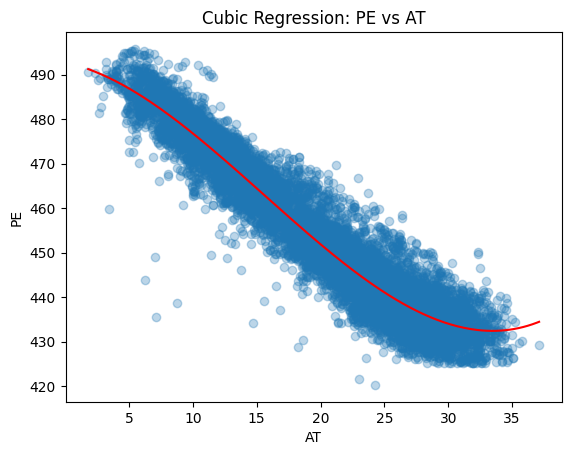

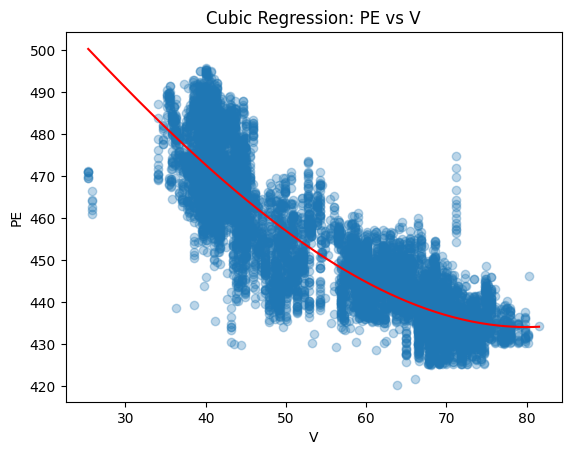

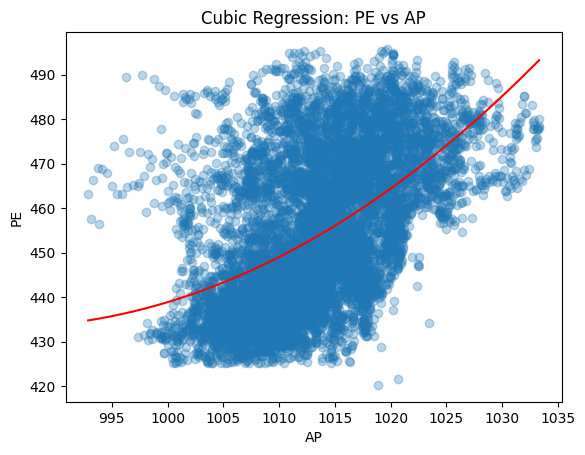

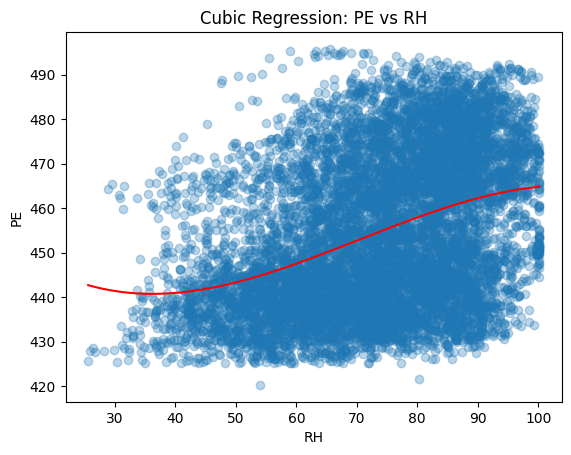

In [70]:
for predictor in predictors:
    model = poly_models[predictor]
    
    x_grid = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        200
    )
    
    X_grid = pd.DataFrame({
        predictor: x_grid,
        f'{predictor}^2': x_grid ** 2,
        f'{predictor}^3': x_grid ** 3
    })
    
    X_grid = sm.add_constant(X_grid, has_constant='add')
    y_pred = model.predict(X_grid)

    plt.scatter(df[predictor], df['PE'], alpha=0.3)
    plt.plot(x_grid, y_pred, color='red')
    plt.xlabel(predictor)
    plt.ylabel('PE')
    plt.title(f'Cubic Regression: PE vs {predictor}')
    plt.show()

- The polynomial terms provide statistically significant evidence of nonlinear associations for the predictors, although the practical magnitude of the nonlinearity varies. 
- Given the large sample size (n = 9,568), very small effects can become statistically significant.
- The joint F-tests show statistically significant evidence of nonlinear associations between each predictor and PE (all p-values < 0.001). However, the improvements in \(R^2\) are relatively modest. The cubic model increases \(R^2\) by approximately 0.0129 for AT, 0.0185 for V, 0.0061 for AP, and only 0.0018 for RH. Therefore, although nonlinear terms are statistically significant for all four predictors, their practical improvement in explanatory power is limited, particularly for AP and RH.

### (g) Interactions of Predictors

In [71]:
interaction_model = smf.ols(
    'PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH',
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:07   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

- There is evidence of interaction effects between some predictors and PE. At the 0.05 significance level, the interaction terms AT×V (p < 0.001), AT×RH (p < 0.001), V×AP (p < 0.001), and AP×RH (p = 0.034) are statistically significant, whereas AT×AP (p = 0.452) and V×RH (p = 0.086) are not.  

- The model with all pairwise interactions has an \(R^2\) of 0.936, compared with 0.929 for the multiple linear regression without interactions. Thus, although several interaction terms are statistically significant, adding the interaction terms provides only a modest improvement in the model's overall explanatory power.

### (h) Improvement

In [72]:
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42
)

In [73]:
model1 = smf.ols(
    'PE ~ AT + V + AP + RH',
    data=train
).fit()

train_pred1 = model1.predict(train)
test_pred1 = model1.predict(test)

train_mse1 = mean_squared_error(train['PE'], train_pred1)
test_mse1 = mean_squared_error(test['PE'], test_pred1)

print("Model 1 Train MSE:", train_mse1)
print("Model 1 Test MSE:", test_mse1)

Model 1 Train MSE: 20.5808397257387
Model 1 Test MSE: 21.239856938225497


In [74]:
full_model = smf.ols(
    '''PE ~ (AT + V + AP + RH)**2
            + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)''',
    data=train
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:07   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

#### Backward elimination of insignificant variables

1. Remove V:RH

In [75]:
model_step1 = smf.ols(
    '''PE ~ AT + V + AP + RH
            + AT:V + AT:AP + AT:RH
            + V:AP + AP:RH
            + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)''',
    data=train
).fit()

print(model_step1.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7832.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:07   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6683   BIC:                         3.844e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7677.4947   1427.498     -5.378      0.0

2. Remove v^2

In [76]:
model_step2 = smf.ols(
    '''PE ~ AT + V + AP + RH
            + AT:V + AT:AP + AT:RH
            + V:AP + AP:RH
            + I(AT**2) + I(AP**2) + I(RH**2)''',
    data=train
).fit()

print(model_step2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     8486.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:07   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6684   BIC:                         3.844e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7693.6035   1427.075     -5.391      0.0

3. Remove V:AP

In [77]:
model_step3 = smf.ols(
    '''PE ~ AT + V + AP + RH
            + AT:V + AT:AP + AT:RH
            + AP:RH
            + I(AT**2) + I(AP**2) + I(RH**2)''',
    data=train
).fit()

print(model_step3.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:50:07   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.0

In [78]:
from sklearn.metrics import mean_squared_error

# Model 1: ordinary multiple linear regression
train_pred1 = model1.predict(train)
test_pred1 = model1.predict(test)

train_mse1 = mean_squared_error(train['PE'], train_pred1)
test_mse1 = mean_squared_error(test['PE'], test_pred1)


# Model 2: final improved model
final_model = model_step3

train_pred2 = final_model.predict(train)
test_pred2 = final_model.predict(test)

train_mse2 = mean_squared_error(train['PE'], train_pred2)
test_mse2 = mean_squared_error(test['PE'], test_pred2)

In [79]:
mse_results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Interaction + Quadratic Model'
    ],
    'Train MSE': [
        train_mse1,
        train_mse2
    ],
    'Test MSE': [
        test_mse1,
        test_mse2
    ]
})

mse_results

,Model,Train MSE,Test MSE
0,Multiple Linear Regression,20.580840,21.239857
1,Interaction + Quadratic Model,17.890843,18.660040


- The data were randomly split into 70% training and 30% test sets. First, a multiple linear regression model containing all four predictors (AT, V, AP, and RH) was fitted. The model achieved a training MSE of 20.581 and a test MSE of 21.240.

- Next, a more flexible model containing all pairwise interaction terms and quadratic terms was fitted on the training set. Insignificant higher-order terms were removed using backward elimination while maintaining the hierarchy principle for interaction terms. The final model retained the interactions AT×V, AT×AP, AT×RH, and AP×RH, as well as the quadratic terms AT², AP², and RH². The final model achieved a training MSE of 17.891 and a test MSE of 18.660.

- Thus, incorporating selected interaction and nonlinear terms improves the model. In particular, the test MSE decreases from 21.240 to 18.660, indicating better out-of-sample predictive performance than the original multiple linear regression model.

### (i) KNN

In [80]:
features = ['AT', 'V', 'AP', 'RH']

X_train = train[features]
y_train = train['PE']

X_test = test[features]
y_test = test['PE']

1. Raw features

In [81]:
k_values = range(1, 101)

train_mse_raw = []
test_mse_raw = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_mse_raw.append(mean_squared_error(y_train, train_pred))
    test_mse_raw.append(mean_squared_error(y_test, test_pred))

In [82]:
best_k_raw = k_values[np.argmin(test_mse_raw)]
best_test_mse_raw = min(test_mse_raw)

print("Best k for raw features:", best_k_raw)
print("Best test MSE for raw features:", best_test_mse_raw)
print("Train MSE at best k:",
      train_mse_raw[best_k_raw - 1])

Best k for raw features: 5
Best test MSE for raw features: 15.726819842563568
Train MSE at best k: 10.600768887561596


2. Normalized features

In [83]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
scaler.fit_transform(X_train)  # 用 training data 学 mean/std
scaler.transform(X_test)       # test 只能 transform

array([[ 0.00218095, -0.48710194,  0.26514899,  0.11006243],
       [ 1.1642821 ,  1.18290186, -0.03750641, -2.1339947 ],
       [ 1.12653403,  1.02039794, -0.99423378,  0.13259861],
       ...,
       [-0.95769842, -1.00932324,  0.4786892 , -0.30105212],
       [-1.33113464, -1.05902104,  2.14665677,  0.7574654 ],
       [ 0.53739459,  0.76559812, -0.05600202,  0.936389  ]],
      shape=(2871, 4))

In [85]:
train_mse_scaled = []
test_mse_scaled = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    train_mse_scaled.append(mean_squared_error(y_train, train_pred))
    test_mse_scaled.append(mean_squared_error(y_test, test_pred))

In [86]:
best_k_scaled = k_values[np.argmin(test_mse_scaled)]
best_test_mse_scaled = min(test_mse_scaled)

print("Best k for normalized features:", best_k_scaled)
print("Best test MSE for normalized features:", best_test_mse_scaled)
print("Train MSE at best k:",
      train_mse_scaled[best_k_scaled - 1])

Best k for normalized features: 4
Best test MSE for normalized features: 14.305669422675024
Train MSE at best k: 8.591432839331045


Visualizations

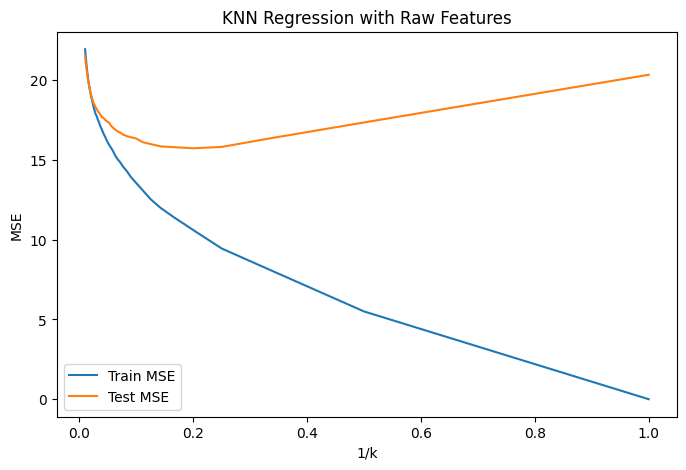

In [87]:
inverse_k = 1 / np.array(list(k_values))

plt.figure(figsize=(8, 5))

plt.plot(inverse_k, train_mse_raw, label='Train MSE')
plt.plot(inverse_k, test_mse_raw, label='Test MSE')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression with Raw Features')
plt.legend()
plt.show()

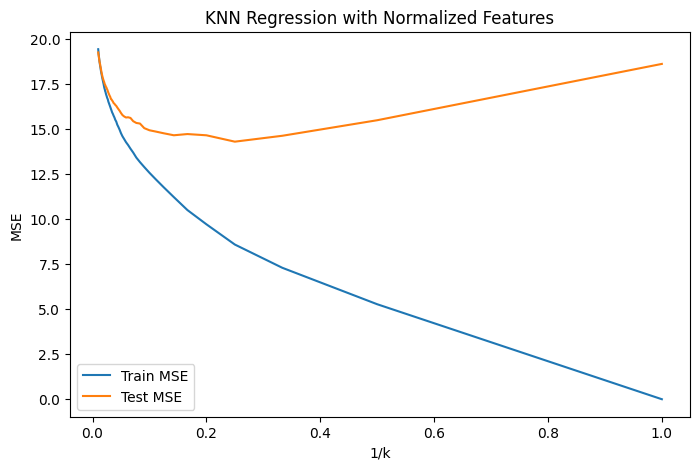

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(inverse_k, train_mse_scaled, label='Train MSE')
plt.plot(inverse_k, test_mse_scaled, label='Test MSE')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression with Normalized Features')
plt.legend()
plt.show()

In [89]:
results_knn = pd.DataFrame({
    'Features': ['Raw', 'Normalized'],
    'Best k': [best_k_raw, best_k_scaled],
    'Train MSE': [
        train_mse_raw[best_k_raw - 1],
        train_mse_scaled[best_k_scaled - 1]
    ],
    'Test MSE': [
        best_test_mse_raw,
        best_test_mse_scaled
    ]
})

results_knn

,Features,Best k,Train MSE,Test MSE
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.591433,14.305669


For the raw features, the optimal value is k = 5, with a training MSE of 10.60 and a test MSE of 15.73. After normalization, the optimal value is k = 4, with a training MSE of 8.59 and a test MSE of 14.31. Thus, normalization improves the performance of KNN regression. The error curves also show that very small \(k\) leads to overfitting, while very large \(k\) leads to underfitting.

### (j ) Compare KNN and Linear

- The best linear regression model, which includes selected interaction and quadratic terms, has a training MSE of 17.89 and a test MSE of 18.66. 

- In comparison, KNN regression performs better, particularly after normalization. The normalized KNN model with \(k=4\) achieves a training MSE of 8.59 and a test MSE of 14.31, reducing the test MSE by approximately 23.3% compared with the best linear regression model. 

- This suggests that KNN is better able to capture the local and nonlinear relationships between the predictors and PE that are not fully represented by the specified linear regression model.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Better. With a very large sample size relative to the number of predictors, a flexible method can estimate complex relationships with relatively low risk of overfitting. It may therefore achieve lower bias without introducing excessive variance.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Worse. With many predictors but few observations, a flexible method is likely to have high variance and overfit the training data. A less flexible method would generally be more stable and may generalize better.

### (c) The relationship between the predictors and response is highly non-linear.

Better. When the true relationship is highly nonlinear, a flexible method is better able to capture the underlying pattern. An inflexible method may have high bias and underfit the data.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Worse. When the error variance is extremely high, much of the variation in the response is random noise. A flexible method is more likely to fit this noise, increasing variance and overfitting without improving the underlying signal.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [90]:
df = pd.DataFrame({
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
})

test_point = np.array([0, 0, 0])

df['Distance'] = np.sqrt(
    (df['X1'] - test_point[0])**2 +
    (df['X2'] - test_point[1])**2 +
    (df['X3'] - test_point[2])**2
)

df

,X1,X2,X3,Y,Distance
0,0,3,0,Red,3.000000
1,2,0,0,Red,2.000000
2,0,1,3,Red,3.162278
3,0,1,2,Green,2.236068
4,-1,0,1,Green,1.414214
5,1,1,1,Red,1.732051


### (b) What is our prediction with K = 1? Why?

In [91]:
X = df[['X1', 'X2', 'X3']]
y = df['Y']

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X, y)

prediction_k1 = knn1.predict([test_point])

print(prediction_k1)

['Green']


/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


With \(K=1\), the prediction is **Green**, since Observation 5 is the  nearest neighbor to the test point.

### (c) What is our prediction with K = 3? Why?

In [92]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X, y)

prediction_k3 = knn3.predict([test_point])

print(prediction_k3)

['Red']


/Users/xiada/keck_venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


The three nearest neighbors are Observations 5, 6, and 2, with class labels Green, Red, and Red. Since Red is the majority class, the predicted response is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the Bayes decision boundary is highly nonlinear, a small K is generally preferred because a smaller K produces a more flexible decision boundary that can better capture nonlinear patterns.